<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 32.3 MB/s eta 0:00:00


Synthesizing Phase-Added Stereogram (PAS)...
PAS Synthesis Complete!


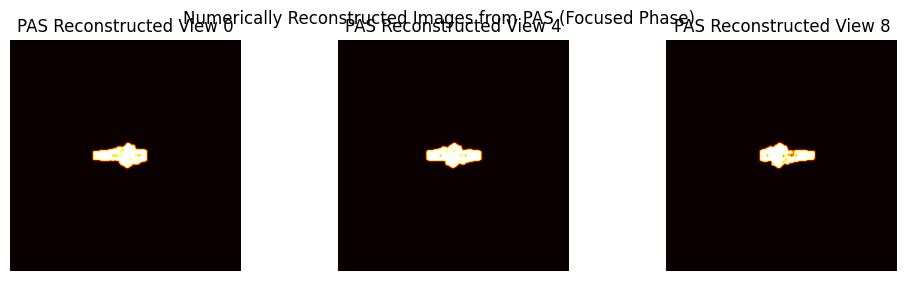

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import trimesh

# ==========================================
# 1. パラメータ設計 (物理定数・解像度)
# ==========================================
N_views = 9           # 視点数
res = 256             # 要素ホログラム(Hogol)の縦横ピクセル数
wavelength = 632.8e-9 # 再生レーザー波長 (赤色: 632.8 nm)
pixel_pitch = 8e-6    # ホログラムの画素ピッチ (8 um)
theta_y = np.deg2rad(1.2) # 参照光のY軸方向の入射角

# 参照光（平面波）の準備
k = 2 * np.pi / wavelength  # k = 2π / λ
y_coords = (np.arange(res) - res // 2) * pixel_pitch
x_coords = (np.arange(res) - res // 2) * pixel_pitch
X, Y = np.meshgrid(x_coords, y_coords)
Reference_Wave = np.exp(-1j * k * Y * np.sin(theta_y))

# ==========================================
# 2. .obj から Light Field (L) と Depth Field (D) を同時生成
# ==========================================
def load_obj_vertices(file_path):
    mesh_or_scene = trimesh.load(file_path)
    if isinstance(mesh_or_scene, trimesh.Scene):
        vertices_list = [np.array(geom.vertices) for geom in mesh_or_scene.geometry.values()]
        vertices = np.vstack(vertices_list)
    else:
        vertices = np.array(mesh_or_scene.vertices)

    # 中心化
    vertices -= np.mean(vertices, axis=0)
    # カメラの画角にフィットするようサイズ正規化 (半径約 30mm の空間に収める)
    max_bound = np.max(np.abs(vertices))
    if max_bound > 0:
        vertices = (vertices / max_bound) * 30.0
    return vertices

def generate_pas_fields_from_obj(file_path, n_views, resolution):
    points_3d = load_obj_vertices(file_path)

    view_L = [] # Light Field バッファ (輝度画像)
    view_D = [] # Depth Field バッファ (奥行き距離)

    # カメラ幾何学パラメータ
    R = 200.0   # 物体中心までの距離 (mm)
    f = 300.0   # 焦点距離

    max_angle = np.deg2rad(20)
    angles = np.linspace(-max_angle, max_angle, n_views)

    for alpha in angles:
        # L（光線強度：黒で初期化）と D（デプス：無限遠で初期化）
        img_L = np.zeros((resolution, resolution))
        img_D = np.zeros((resolution, resolution)) # 物理的な距離(mm)が入る

        for pt in points_3d:
            # カメラ座標系への回転・平行移動
            x_rot = pt[0] * np.cos(alpha) - pt[2] * np.sin(alpha)
            y_rot = pt[1]
            z_rot = pt[0] * np.sin(alpha) + pt[2] * np.cos(alpha) + R # これが実際の奥行き距離(mm)

            # 透視投影計算
            proj_x = int(resolution // 2 + (x_rot * f / z_rot))
            proj_y = int(resolution // 2 + (y_rot * f / z_rot))

            if 0 <= proj_x < resolution and 0 <= proj_y < resolution:
                # 輝度の記録 (重ね描きにより密度を表現)
                img_L[proj_y, proj_x] = 255.0

                # Zバッファ（手前にあるものを優先してデプスを記録）
                current_depth = z_rot
                if img_D[proj_y, proj_x] == 0 or current_depth < img_D[proj_y, proj_x]:
                    img_D[proj_y, proj_x] = current_depth

        # 描画を滑らかにするための最小限の処理
        img_L = cv2.GaussianBlur(img_L, (3, 3), 0) / 255.0
        # デプスの未記録部分（背景0）は、計算の破綻を防ぐために基準距離R（中心）で埋める
        img_D[img_D == 0] = R

        # 物理単位をミリメートルからメートルに変換
        img_D_meters = img_D * 1e-3

        view_L.append(img_L)
        view_D.append(img_D_meters)

    return view_L, view_D

# --- .obj ファイルの指定 ---
obj_path = "/content/13506_Diamond_Ring_v1_l3.obj" # アップロードしたファイル名に変更してください
view_L, view_D = generate_pas_fields_from_obj(obj_path, N_views, res)

# ==========================================
# 3. PAS (Phase-Added Stereogram) アルゴリズムによるHS合成
# ==========================================
pas_hologram = np.zeros((res, res * N_views), dtype=np.complex128)

print("Synthesizing Phase-Added Stereogram (PAS)...")
for v_idx in range(N_views):
    L = view_L[v_idx] # Light Field (強度)
    D = view_D[v_idx] # Depth Field (奥行き距離 m)

    # 振幅 √L
    amplitude = np.sqrt(L)

    # 論文の重要数式：STFT = √L * exp( i * 2π/λ * D )
    # 物理的な奥行き情報を直接位相に変換して付加
    phase_pas = k * D
    complex_object = amplitude * np.exp(1j * phase_pas)

    # 2次元FFTにより要素ホログラム面へ展開
    U_object = np.fft.fftshift(np.fft.fft2(complex_object))

    # 参照光との干渉
    fringe = U_object * np.conj(Reference_Wave)

    start_col = v_idx * res
    end_col = start_col + res
    pas_hologram[:, start_col:end_col] = fringe

print("PAS Synthesis Complete!")

# ==========================================
# 4. 数値的再生シミュレーション
# ==========================================
plt.figure(figsize=(12, 3))
for i, v_idx in enumerate([0, N_views//2, N_views-1]):
    start_col = v_idx * res
    hogol_part = pas_hologram[:, start_col:start_col+res]

    reconstructed_complex = np.fft.ifft2(np.fft.ifftshift(hogol_part * Reference_Wave))
    reconstructed_intensity = np.abs(reconstructed_complex)**2

    plt.subplot(1, 3, i+1)
    plt.imshow(reconstructed_intensity, cmap='hot')
    plt.title(f"PAS Reconstructed View {v_idx}")
    plt.axis('off')
plt.suptitle("Numerically Reconstructed Images from PAS (Focused Phase)")
plt.show()